In [6]:
import tensorflow as tf
from tensorflow import keras
import json

# Custom functions
def combined_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.7 * mae + 0.3 * ssim

def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

# Load config
with open("final_dehaze_model.keras/config.json") as f:
    config = json.load(f)

# Rebuild model
model = keras.models.model_from_json(
    json.dumps(config),
    custom_objects={
        "combined_loss": combined_loss,
        "psnr_metric": psnr_metric
    }
)

# Load weights
model.load_weights("final_dehaze_model.keras/model.weights.h5")

print("Model loaded successfully")

E0000 00:00:1777737250.544458  349929 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
hazy_images = []
gt_images = []

IMG_SIZE = 128

files = sorted(os.listdir(HAZY_PATH))[:50]  # use 50 images for testing

for file in files:
    hazy = cv2.imread(os.path.join(HAZY_PATH, file))
    gt = cv2.imread(os.path.join(GT_PATH, file))

    if hazy is None or gt is None:
        continue

    hazy = cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    hazy = cv2.resize(hazy, (IMG_SIZE, IMG_SIZE))
    gt = cv2.resize(gt, (IMG_SIZE, IMG_SIZE))

    hazy = hazy.astype(np.float32) / 255.0
    gt = gt.astype(np.float32) / 255.0

    hazy_images.append(hazy)
    gt_images.append(gt)

X = np.array(hazy_images)
Y = np.array(gt_images)

print("Data Loaded:", X.shape)


Data Loaded: (50, 128, 128, 3)


In [25]:
pred = model.predict(X) 
pred = pred.astype(np.float32)


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step



 METRICS
PSNR Before : 19.5092
PSNR After  : 29.2699
SSIM Before : 0.8811
SSIM After  : 0.9599
MAE Before  : 0.1011
MAE After   : 0.0275


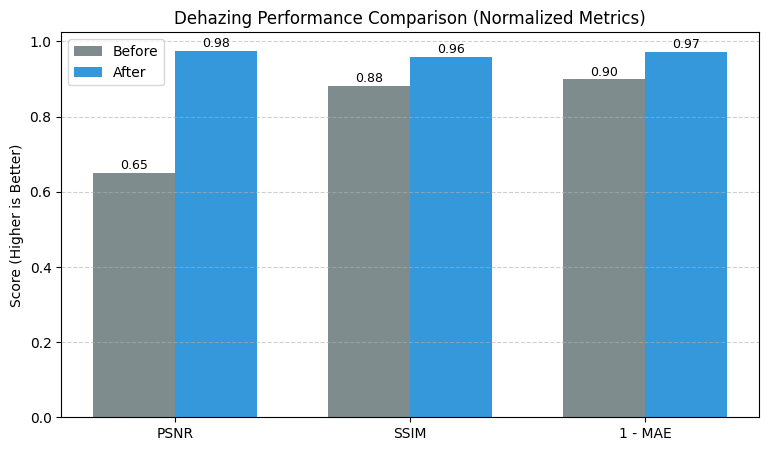

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ===== METRICS =====
psnr_before = tf.image.psnr(X, Y, max_val=1.0)
psnr_after  = tf.image.psnr(pred, Y, max_val=1.0)

ssim_before = tf.image.ssim(X, Y, max_val=1.0)
ssim_after  = tf.image.ssim(pred, Y, max_val=1.0)
mae_before = np.mean(np.abs(X - Y))
mae_after  = np.mean(np.abs(pred - Y))

# Convert to scalars
psnr_b = float(np.mean(psnr_before))
psnr_a = float(np.mean(psnr_after))

ssim_b = float(np.mean(ssim_before))
ssim_a = float(np.mean(ssim_after))


mae_b = 1 - mae_before
mae_a = 1 - mae_after

psnr_b /= 30
psnr_a /= 30


print("\n METRICS")
print(f"PSNR Before : {psnr_b*30:.4f}")
print(f"PSNR After  : {psnr_a*30:.4f}")
print(f"SSIM Before : {ssim_b:.4f}")
print(f"SSIM After  : {ssim_a:.4f}")
print(f"MAE Before  : {mae_before:.4f}")
print(f"MAE After   : {mae_after:.4f}")


metrics = ['PSNR', 'SSIM', '1 - MAE']

before = [psnr_b, ssim_b, mae_b]
after  = [psnr_a, ssim_a, mae_a]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))

bars1 = plt.bar(x - width/2, before, width, label='Before', color='#7f8c8d')
bars2 = plt.bar(x + width/2, after, width, label='After', color='#3498db')

plt.xticks(x, metrics)
plt.title('Dehazing Performance Comparison (Normalized Metrics)')
plt.ylabel('Score (Higher is Better)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}",
             ha='center', fontsize=9)

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}",
             ha='center', fontsize=9)

plt.show()

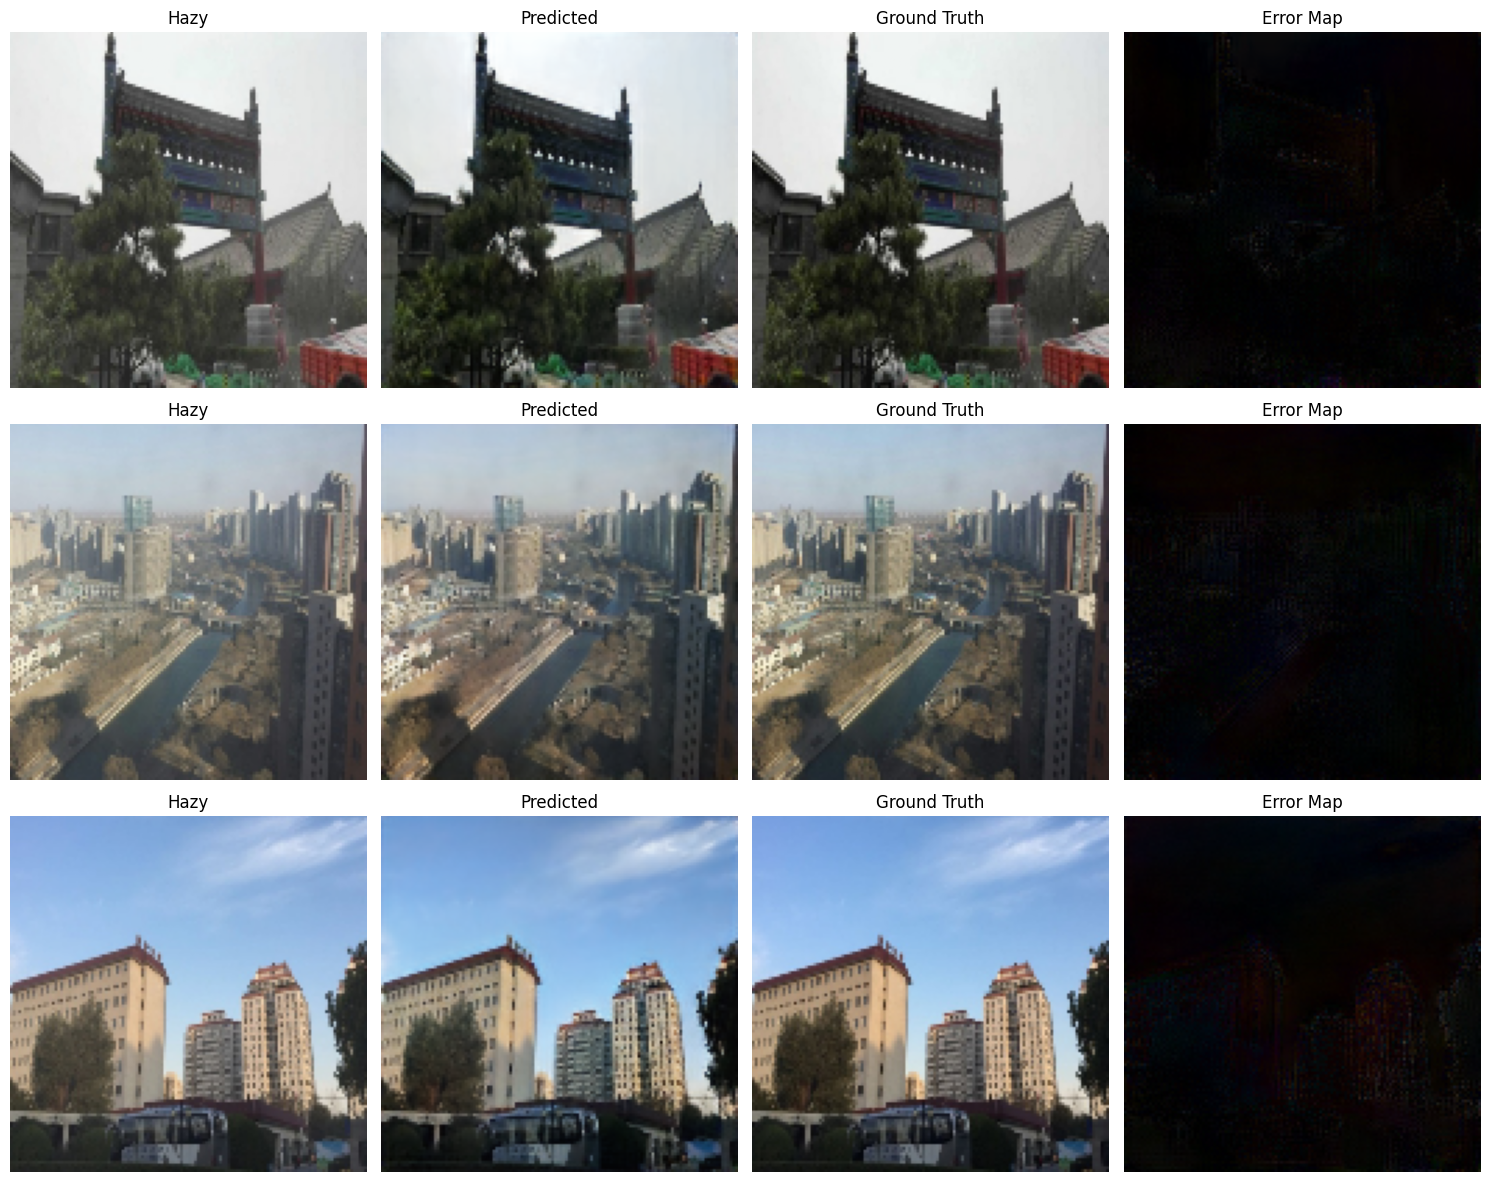

In [31]:
n = 3
plt.figure(figsize=(15, 12))

for i in range(n):
    idx = min(i, len(X)-1)

    # Hazy
    plt.subplot(n, 4, i*4 + 1)
    plt.imshow(X[idx])
    plt.title("Hazy")
    plt.axis("off")

    # Predicted
    plt.subplot(n, 4, i*4 + 2)
    plt.imshow(pred[idx])
    plt.title("Predicted")
    plt.axis("off")

    # Ground Truth
    plt.subplot(n, 4, i*4 + 3)
    plt.imshow(Y[idx])
    plt.title("Ground Truth")
    plt.axis("off")

    # Error Map
    error = np.abs(pred[idx] - Y[idx])
    plt.subplot(n, 4, i*4 + 4)
    plt.imshow(error)
    plt.title("Error Map")
    plt.axis("off")

plt.tight_layout()
plt.show()



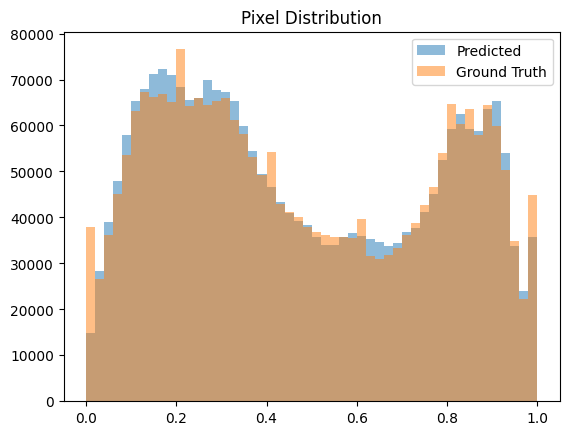

In [32]:
plt.hist(pred.flatten(), bins=50, alpha=0.5, label='Predicted')
plt.hist(Y.flatten(), bins=50, alpha=0.5, label='Ground Truth')
plt.legend()
plt.title("Pixel Distribution")
plt.show()

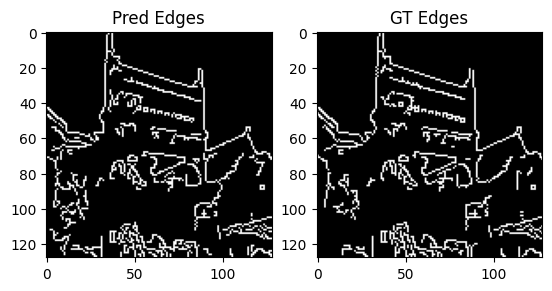

In [29]:
IMG_SIZE = 128

sample = 0

pred_img = cv2.cvtColor((pred[sample]*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gt_img   = cv2.cvtColor((Y[sample]*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

edges_pred = cv2.Canny(pred_img, 100, 200)
edges_gt = cv2.Canny(gt_img, 100, 200)

plt.subplot(1,2,1)
plt.imshow(edges_pred, cmap='gray')
plt.title("Pred Edges")

plt.subplot(1,2,2)
plt.imshow(edges_gt, cmap='gray')
plt.title("GT Edges")

plt.show()